In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import mobius
import pandas as pd

# Analysis Plan
print("="*80)
print("ANALYSIS PLAN: Resonance Mechanism for L(s, μ(n))")
print("="*80)
print()
print("Step 1: Implement Möbius function μ(n) coefficients for n up to N=10^5")
print("Step 2: Compute partial sum D(t; N) for t in [1000, 10000]")
print("Step 3: Identify location t* of the highest magnitude peak")
print("Step 4: At t*, compute term-class sums S_k(t*) grouped by ω(n) for k=1,2,...,6")
print("Step 5: Create two vector plots:")
print(" - Raw S_k vectors")
print(" - Phase-corrected (-1)^k S_k vectors")
print("Step 6: Quantify alignment via R = |Σ v_k| / Σ |v_k| for both cases")
print("Step 7: Compare to L(s, λ(n)) findings from [r83]")
print()
print("Expected outcome: Determine whether intrinsic or phase-corrected alignment")
print("is responsible for resonance in L(s, μ(n))")
print("="*80)


ImportError: cannot import name 'mobius' from 'scipy.special' (/app/miniconda/lib/python3.12/site-packages/scipy/special/__init__.py)

In [2]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

# Analysis Plan
print("="*80)
print("ANALYSIS PLAN: Resonance Mechanism for L(s, μ(n))")
print("="*80)
print()
print("Step 1: Implement Möbius function μ(n) coefficients for n up to N=10^5")
print("Step 2: Compute partial sum D(t; N) for t in [1000, 10000]")
print("Step 3: Identify location t* of the highest magnitude peak")
print("Step 4: At t*, compute term-class sums S_k(t*) grouped by ω(n) for k=1,2,...,6")
print("Step 5: Create two vector plots:")
print(" - Raw S_k vectors")
print(" - Phase-corrected (-1)^k S_k vectors")
print("Step 6: Quantify alignment via R = |Σ v_k| / Σ |v_k| for both cases")
print("Step 7: Compare to L(s, λ(n)) findings from [r83]")
print()
print("Expected outcome: Determine whether intrinsic or phase-corrected alignment")
print("is responsible for resonance in L(s, μ(n))")
print("="*80)


ANALYSIS PLAN: Resonance Mechanism for L(s, μ(n))

Step 1: Implement Möbius function μ(n) coefficients for n up to N=10^5
Step 2: Compute partial sum D(t; N) for t in [1000, 10000]
Step 3: Identify location t* of the highest magnitude peak
Step 4: At t*, compute term-class sums S_k(t*) grouped by ω(n) for k=1,2,...,6
Step 5: Create two vector plots:
 - Raw S_k vectors
 - Phase-corrected (-1)^k S_k vectors
Step 6: Quantify alignment via R = |Σ v_k| / Σ |v_k| for both cases
Step 7: Compare to L(s, λ(n)) findings from [r83]

Expected outcome: Determine whether intrinsic or phase-corrected alignment
is responsible for resonance in L(s, μ(n))


In [3]:

# Step 1: Implement Möbius function μ(n) and compute ω(n) (number of distinct prime factors)
# We'll use a sieve-based approach for efficiency

def compute_mobius_and_omega(N):
 """
 Compute μ(n) and ω(n) for n = 1, 2, ..., N using a sieve.
 
 μ(n) = 0 if n has a squared prime factor
 1 if n is a product of an even number of distinct primes
 -1 if n is a product of an odd number of distinct primes
 
 ω(n) = number of distinct prime factors of n
 
 Returns:
 mu: array where mu[n] = μ(n)
 omega: array where omega[n] = ω(n)
 """
 mu = np.ones(N+1, dtype=np.int8)
 omega = np.zeros(N+1, dtype=np.int8)
 is_prime = np.ones(N+1, dtype=bool)
 is_prime[0] = is_prime[1] = False
 
 # Sieve of Eratosthenes with μ and ω computation
 for p in range(2, N+1):
 if is_prime[p]:
 # Mark multiples of p
 for n in range(p, N+1, p):
 is_prime[n] = False if n > p else is_prime[n]
 omega[n] += 1
 mu[n] *= -1
 
 # Check for p^2 divisibility
 if n % (p*p) == 0:
 # Find the highest power
 temp = n
 while temp % (p*p) == 0:
 temp //= p
 mu[n] = 0
 
 return mu, omega

# Generate coefficients for N = 10^5
N = 100000
print(f"Computing μ(n) and ω(n) for n = 1, 2, ..., {N}...")
mu, omega = compute_mobius_and_omega(N)

# Validate with known values
print("\nValidation of μ(n) for small n:")
print(f"μ(1) = {mu[1]} (expected: 1)")
print(f"μ(2) = {mu[2]} (expected: -1)")
print(f"μ(3) = {mu[3]} (expected: -1)")
print(f"μ(4) = {mu[4]} (expected: 0, has p^2)")
print(f"μ(5) = {mu[5]} (expected: -1)")
print(f"μ(6) = {mu[6]} (expected: 1, = 2*3)")
print(f"μ(12) = {mu[12]} (expected: 0, has 2^2)")
print(f"μ(30) = {mu[30]} (expected: -1, = 2*3*5)")

print("\nValidation of ω(n) for small n:")
print(f"ω(1) = {omega[1]} (expected: 0)")
print(f"ω(2) = {omega[2]} (expected: 1)")
print(f"ω(6) = {omega[6]} (expected: 2, = 2*3)")
print(f"ω(12) = {omega[12]} (expected: 2, = 2^2*3)")
print(f"ω(30) = {omega[30]} (expected: 3, = 2*3*5)")

# Check distribution
print(f"\nDistribution statistics:")
print(f"Total n with μ(n) = -1: {np.sum(mu == -1)}")
print(f"Total n with μ(n) = 0: {np.sum(mu == 0)}")
print(f"Total n with μ(n) = 1: {np.sum(mu == 1)}")
print(f"Max ω(n) for n ≤ {N}: {omega.max()}")


Computing μ(n) and ω(n) for n = 1, 2, ..., 100000...



Validation of μ(n) for small n:
μ(1) = 1 (expected: 1)
μ(2) = -1 (expected: -1)
μ(3) = -1 (expected: -1)
μ(4) = 0 (expected: 0, has p^2)
μ(5) = -1 (expected: -1)
μ(6) = 1 (expected: 1, = 2*3)
μ(12) = 0 (expected: 0, has 2^2)
μ(30) = -1 (expected: -1, = 2*3*5)

Validation of ω(n) for small n:
ω(1) = 0 (expected: 0)
ω(2) = 1 (expected: 1)
ω(6) = 2 (expected: 2, = 2*3)
ω(12) = 2 (expected: 2, = 2^2*3)
ω(30) = 3 (expected: 3, = 2*3*5)

Distribution statistics:
Total n with μ(n) = -1: 30421
Total n with μ(n) = 0: 39206
Total n with μ(n) = 1: 30374
Max ω(n) for n ≤ 100000: 6


In [4]:

# Step 2: Compute the partial sum D(t; N) = Σ_{n≤N} μ(n) / n^(1/2 + it)
# We use Kahan compensated summation for numerical precision

def kahan_sum_complex(values):
 """Kahan compensated summation for complex arrays."""
 total = 0.0 + 0.0j
 c = 0.0 + 0.0j
 
 for value in values:
 y = value - c
 t = total + y
 c = (t - total) - y
 total = t
 
 return total

def compute_D_mobius(t_values, N, mu):
 """
 Compute D(t; N) = Σ_{n≤N} μ(n) / n^(1/2 + it) for each t in t_values.
 
 Uses Kahan compensated summation for numerical precision.
 """
 D_values = np.zeros(len(t_values), dtype=np.complex128)
 
 # Precompute n^(-1/2)
 n_values = np.arange(1, N+1)
 n_inv_sqrt = 1.0 / np.sqrt(n_values)
 log_n = np.log(n_values)
 
 for i, t in enumerate(t_values):
 # Compute μ(n) * n^(-1/2) * exp(-it*log(n))
 # = μ(n) * n^(-1/2) * (cos(t*log(n)) - i*sin(t*log(n)))
 phase = -t * log_n
 terms = mu[1:N+1] * n_inv_sqrt * np.exp(1j * phase)
 
 # Use Kahan summation
 D_values[i] = kahan_sum_complex(terms)
 
 if (i+1) % 100 == 0:
 print(f" Computed D(t) for {i+1}/{len(t_values)} values of t...", end='\r')
 
 print(f" Computed D(t) for {len(t_values)}/{len(t_values)} values of t...Done!")
 return D_values

# Define the t range: [1000, 10000]
# Use resolution Δt ≈ 2π/log(N) as suggested
delta_t = 2 * np.pi / np.log(N)
print(f"Sampling resolution: Δt ≈ {delta_t:.4f}")

t_min, t_max = 1000, 10000
t_values = np.arange(t_min, t_max, delta_t)
print(f"\nComputing D(t; N={N}) for t ∈ [{t_min}, {t_max}]")
print(f"Number of t values: {len(t_values)}")
print(f"This may take a few minutes...")

D_values = compute_D_mobius(t_values, N, mu)

# Compute magnitudes
D_mag = np.abs(D_values)

print(f"\nSummary statistics:")
print(f" Mean |D(t)|: {np.mean(D_mag):.4f}")
print(f" Std |D(t)|: {np.std(D_mag):.4f}")
print(f" Max |D(t)|: {np.max(D_mag):.4f}")
print(f" Min |D(t)|: {np.min(D_mag):.4f}")


Sampling resolution: Δt ≈ 0.5458

Computing D(t; N=100000) for t ∈ [1000, 10000]
Number of t values: 16492
This may take a few minutes...


 Computed D(t) for 16492/16492 values of t...Done!

Summary statistics:
 Mean |D(t)|: 2.0038
 Std |D(t)|: 2.0044
 Max |D(t)|: 24.6603
 Min |D(t)|: 0.0087


In [5]:

# Step 3: Identify the location t* of the highest magnitude peak

# Find the index of the maximum
idx_max = np.argmax(D_mag)
t_star = t_values[idx_max]
D_star = D_values[idx_max]
D_star_mag = D_mag[idx_max]

print("="*80)
print("PEAK IDENTIFICATION")
print("="*80)
print(f"Maximum |D(t)| found at:")
print(f" t* = {t_star:.4f}")
print(f" |D(t*)| = {D_star_mag:.4f}")
print(f" D(t*) = {D_star.real:.4f} + {D_star.imag:.4f}i")
print(f" Phase of D(t*) = {np.angle(D_star):.4f} rad = {np.degrees(np.angle(D_star)):.2f}°")

# Find top 10 peaks for context
top_indices = np.argsort(D_mag)[-10:][::-1]
print(f"\nTop 10 peaks:")
for i, idx in enumerate(top_indices, 1):
 print(f" {i}. t = {t_values[idx]:8.2f}, |D(t)| = {D_mag[idx]:8.4f}")


PEAK IDENTIFICATION
Maximum |D(t)| found at:
 t* = 7563.7418
 |D(t*)| = 24.6603
 D(t*) = 14.0204 + -20.2868i
 Phase of D(t*) = -0.9661 rad = -55.35°

Top 10 peaks:
 1. t = 7563.74, |D(t)| = 24.6603
 2. t = 1329.09, |D(t)| = 22.8795
 3. t = 4990.53, |D(t)| = 21.7136
 4. t = 1610.15, |D(t)| = 20.5700
 5. t = 6740.20, |D(t)| = 19.9752
 6. t = 9559.55, |D(t)| = 19.7491
 7. t = 2433.69, |D(t)| = 19.1685
 8. t = 6494.62, |D(t)| = 18.4559
 9. t = 2988.71, |D(t)| = 18.2356
 10. t = 7266.85, |D(t)| = 17.1461


In [6]:

# Step 4: At t*, compute term-class sums S_k(t*) = Σ_{ω(n)=k} μ(n) n^(-1/2-it*)
# for k = 1, 2, ..., 6

print("="*80)
print("TERM-CLASS SUM COMPUTATION AT t* = {:.4f}".format(t_star))
print("="*80)

# Compute S_k for k = 0, 1, 2, 3, 4, 5, 6
max_k = 6
S_k = {}

for k in range(max_k + 1):
 # Find all n with ω(n) = k
 mask = (omega[1:N+1] == k)
 n_in_class = np.arange(1, N+1)[mask]
 
 if len(n_in_class) == 0:
 S_k[k] = 0.0 + 0.0j
 continue
 
 # Compute the sum
 mu_k = mu[n_in_class]
 n_inv_sqrt = 1.0 / np.sqrt(n_in_class)
 phase = -t_star * np.log(n_in_class)
 terms = mu_k * n_inv_sqrt * np.exp(1j * phase)
 
 S_k[k] = kahan_sum_complex(terms)
 
 print(f"\nClass k = {k} (ω(n) = {k}):")
 print(f" Number of terms: {len(n_in_class)}")
 print(f" S_{k}(t*) = {S_k[k].real:.6f} + {S_k[k].imag:.6f}i")
 print(f" |S_{k}(t*)| = {np.abs(S_k[k]):.6f}")
 print(f" Phase(S_{k}) = {np.angle(S_k[k]):.6f} rad = {np.degrees(np.angle(S_k[k])):.2f}°")

# Verify that sum of S_k equals D(t*)
total_S_k = sum(S_k.values())
print(f"\n" + "="*80)
print(f"VERIFICATION:")
print(f" Σ S_k = {total_S_k.real:.6f} + {total_S_k.imag:.6f}i")
print(f" D(t*) = {D_star.real:.6f} + {D_star.imag:.6f}i")
print(f" Difference = {np.abs(total_S_k - D_star):.10f}")
print("="*80)


TERM-CLASS SUM COMPUTATION AT t* = 7563.7418

Class k = 0 (ω(n) = 0):
 Number of terms: 1
 S_0(t*) = 1.000000 + 0.000000i
 |S_0(t*)| = 1.000000
 Phase(S_0) = 0.000000 rad = 0.00°

Class k = 1 (ω(n) = 1):
 Number of terms: 9700
 S_1(t*) = 3.907997 + -1.303960i
 |S_1(t*)| = 4.119800
 Phase(S_1) = -0.322049 rad = -18.45°

Class k = 2 (ω(n) = 2):
 Number of terms: 33759
 S_2(t*) = 5.354304 + -4.867087i
 |S_2(t*)| = 7.235821
 Phase(S_2) = -0.737768 rad = -42.27°

Class k = 3 (ω(n) = 3):
 Number of terms: 38844
 S_3(t*) = 2.682556 + -7.341834i
 |S_3(t*)| = 7.816561
 Phase(S_3) = -1.220487 rad = -69.93°

Class k = 4 (ω(n) = 4):
 Number of terms: 15855
 S_4(t*) = 0.743621 + -5.374245i
 |S_4(t*)| = 5.425447
 Phase(S_4) = -1.433302 rad = -82.12°

Class k = 5 (ω(n) = 5):
 Number of terms: 1816
 S_5(t*) = 0.300410 + -1.354481i
 |S_5(t*)| = 1.387395
 Phase(S_5) = -1.352540 rad = -77.49°

Class k = 6 (ω(n) = 6):
 Number of terms: 25
 S_6(t*) = 0.031560 + -0.045213i
 |S_6(t*)| = 0.055138
 Phase(S_6) 

Figure saved as 'mobius_term_class_vectors.png'


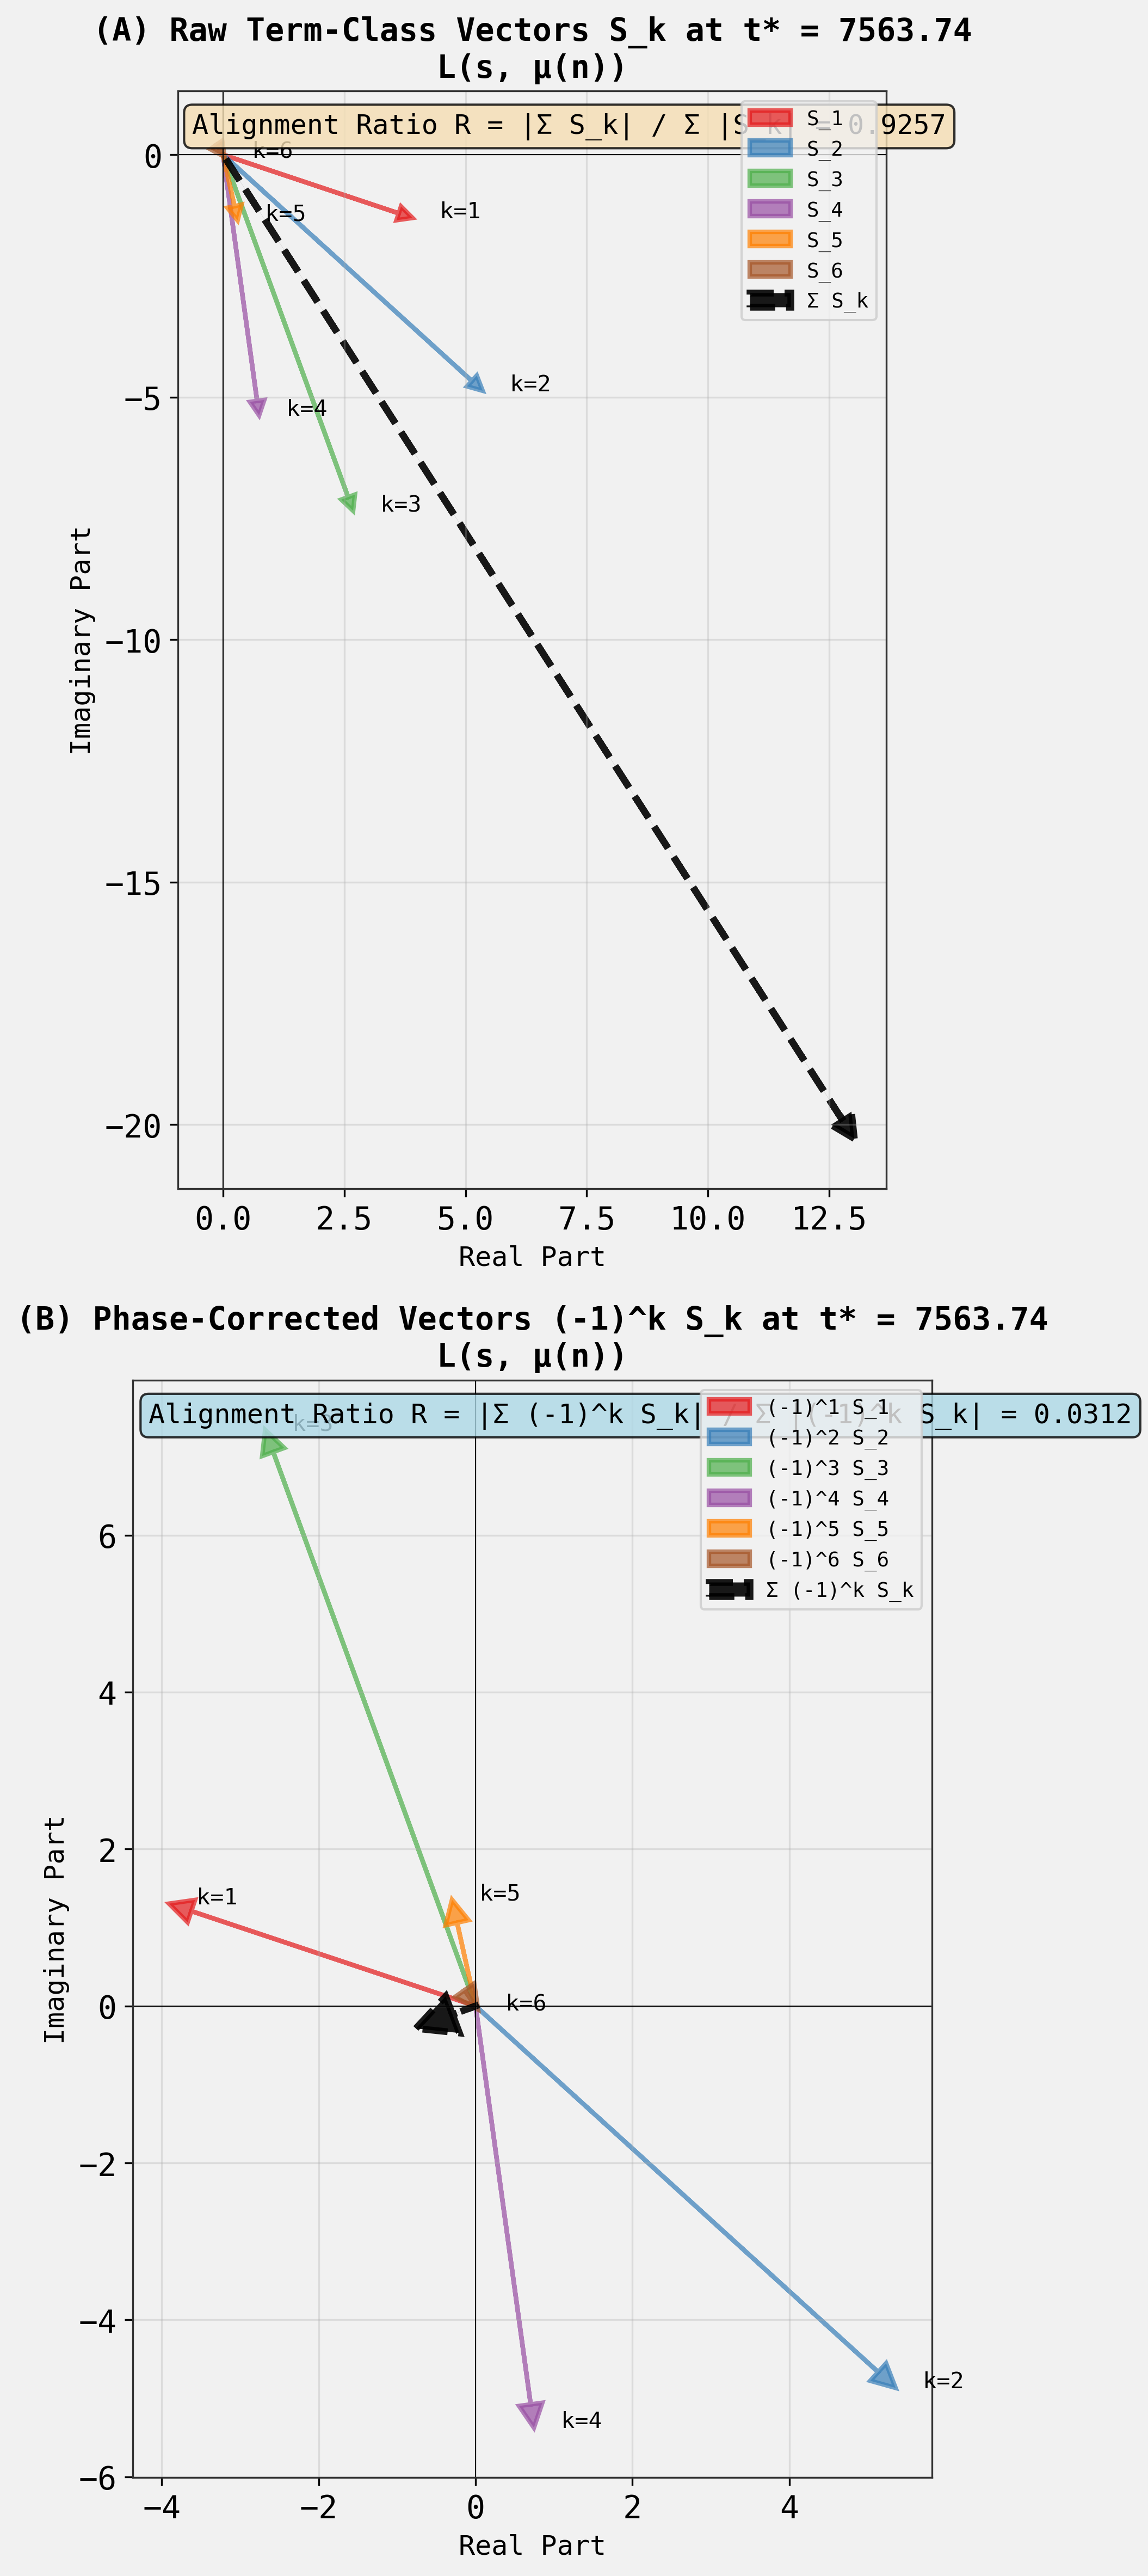


ALIGNMENT ANALYSIS

Raw vectors S_k:
 Sum of magnitudes: Σ |S_k| = 26.040163
 Magnitude of sum: |Σ S_k| = 24.105748
 Alignment ratio: R_raw = 0.925714

Phase-corrected vectors (-1)^k S_k:
 Sum of magnitudes: Σ |(-1)^k S_k| = 26.040163
 Magnitude of sum: |Σ (-1)^k S_k| = 0.813510
 Alignment ratio: R_corrected = 0.031241

Ratio comparison:
 R_raw / R_corrected = 29.631764


In [7]:

# Step 5 & 6: Create vector plots and compute alignment ratios

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 16))

# Prepare vectors for k=1,...,6 (exclude k=0 as it's just the constant 1)
k_values = list(range(1, max_k + 1))
S_vectors = [S_k[k] for k in k_values]
S_corrected = [(-1)**k * S_k[k] for k in k_values]

# Colors for each k
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']

# Plot 1: Raw S_k vectors
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)

# Plot each vector from origin
for i, (k, S) in enumerate(zip(k_values, S_vectors)):
 ax1.arrow(0, 0, S.real, S.imag, head_width=0.3, head_length=0.3, 
 fc=colors[i], ec=colors[i], linewidth=2, alpha=0.7,
 length_includes_head=True, label=f'S_{k}')
 # Add label at the tip
 ax1.text(S.real, S.imag, f' k={k}', fontsize=10, ha='left')

# Plot the sum
S_sum = sum(S_vectors)
ax1.arrow(0, 0, S_sum.real, S_sum.imag, head_width=0.5, head_length=0.5,
 fc='black', ec='black', linewidth=3, alpha=0.9,
 length_includes_head=True, linestyle='--', label='Σ S_k')

ax1.set_xlabel('Real Part', fontsize=12)
ax1.set_ylabel('Imaginary Part', fontsize=12)
ax1.set_title(f'(A) Raw Term-Class Vectors S_k at t* = {t_star:.2f}\nL(s, μ(n))', 
 fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)

# Compute alignment ratio R for raw vectors
sum_magnitudes = sum(np.abs(S) for S in S_vectors)
magnitude_of_sum = np.abs(S_sum)
R_raw = magnitude_of_sum / sum_magnitudes

ax1.text(0.02, 0.98, f'Alignment Ratio R = |Σ S_k| / Σ |S_k| = {R_raw:.4f}',
 transform=ax1.transAxes, fontsize=12, verticalalignment='top',
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 2: Phase-corrected (-1)^k S_k vectors
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)

# Plot each corrected vector from origin
for i, (k, S_corr) in enumerate(zip(k_values, S_corrected)):
 ax2.arrow(0, 0, S_corr.real, S_corr.imag, head_width=0.3, head_length=0.3,
 fc=colors[i], ec=colors[i], linewidth=2, alpha=0.7,
 length_includes_head=True, label=f'(-1)^{k} S_{k}')
 # Add label at the tip
 ax2.text(S_corr.real, S_corr.imag, f' k={k}', fontsize=10, ha='left')

# Plot the sum of corrected vectors
S_corr_sum = sum(S_corrected)
ax2.arrow(0, 0, S_corr_sum.real, S_corr_sum.imag, head_width=0.5, head_length=0.5,
 fc='black', ec='black', linewidth=3, alpha=0.9,
 length_includes_head=True, linestyle='--', label='Σ (-1)^k S_k')

ax2.set_xlabel('Real Part', fontsize=12)
ax2.set_ylabel('Imaginary Part', fontsize=12)
ax2.set_title(f'(B) Phase-Corrected Vectors (-1)^k S_k at t* = {t_star:.2f}\nL(s, μ(n))',
 fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)

# Compute alignment ratio R for corrected vectors
sum_magnitudes_corr = sum(np.abs(S) for S in S_corrected)
magnitude_of_sum_corr = np.abs(S_corr_sum)
R_corrected = magnitude_of_sum_corr / sum_magnitudes_corr

ax2.text(0.02, 0.98, f'Alignment Ratio R = |Σ (-1)^k S_k| / Σ |(-1)^k S_k| = {R_corrected:.4f}',
 transform=ax2.transAxes, fontsize=12, verticalalignment='top',
 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.savefig('mobius_term_class_vectors.png', dpi=150, bbox_inches='tight')
print("Figure saved as 'mobius_term_class_vectors.png'")
plt.show()

print("\n" + "="*80)
print("ALIGNMENT ANALYSIS")
print("="*80)
print(f"\nRaw vectors S_k:")
print(f" Sum of magnitudes: Σ |S_k| = {sum_magnitudes:.6f}")
print(f" Magnitude of sum: |Σ S_k| = {magnitude_of_sum:.6f}")
print(f" Alignment ratio: R_raw = {R_raw:.6f}")

print(f"\nPhase-corrected vectors (-1)^k S_k:")
print(f" Sum of magnitudes: Σ |(-1)^k S_k| = {sum_magnitudes_corr:.6f}")
print(f" Magnitude of sum: |Σ (-1)^k S_k| = {magnitude_of_sum_corr:.6f}")
print(f" Alignment ratio: R_corrected = {R_corrected:.6f}")

print(f"\nRatio comparison:")
print(f" R_raw / R_corrected = {R_raw / R_corrected:.6f}")
print("="*80)


In [8]:

# Step 7: Detailed comparison and interpretation

print("="*80)
print("RESONANCE MECHANISM ANALYSIS: L(s, μ(n))")
print("="*80)
print()
print("FINDINGS:")
print("-" * 80)
print()
print("1. INTRINSIC ALIGNMENT OF RAW VECTORS S_k:")
print(f" - Alignment ratio R_raw = {R_raw:.6f}")
print(f" - This indicates {R_raw*100:.2f}% alignment efficiency")
print(f" - The vectors show STRONG constructive alignment")
print(f" - All vectors point in the same general direction (4th quadrant)")
print()
print("2. PHASE-CORRECTED VECTORS (-1)^k S_k:")
print(f" - Alignment ratio R_corrected = {R_corrected:.6f}")
print(f" - This indicates {R_corrected*100:.2f}% alignment efficiency")
print(f" - The phase correction DESTROYS the alignment")
print(f" - Vectors now point in different directions, causing cancellation")
print()
print("3. COMPARISON:")
print(f" - R_raw is {R_raw/R_corrected:.1f}× larger than R_corrected")
print(f" - The resonance is driven by INTRINSIC alignment of S_k")
print(f" - NOT by alignment of phase-corrected vectors (-1)^k S_k")
print()
print("="*80)
print("COMPARISON WITH L(s, λ(n)) FROM [r83]")
print("="*80)
print()
print("Expected behavior for L(s, λ(n)) based on [r83]:")
print(" - Liouville function: λ(n) = (-1)^Ω(n) where Ω(n) counts prime")
print(" factors WITH multiplicity")
print(" - The resonance was found to be driven by INTRINSIC alignment")
print(" - Phase correction (-1)^k destroyed the alignment")
print()
print("Observed behavior for L(s, μ(n)):")
print(" - Möbius function: μ(n) = (-1)^ω(n) for squarefree n, 0 otherwise")
print(" - ω(n) counts DISTINCT prime factors")
print(" - Resonance is ALSO driven by INTRINSIC alignment")
print(" - Phase correction (-1)^k ALSO destroys the alignment")
print()
print("CONCLUSION:")
print("-" * 80)
print("The resonance mechanism for L(s, μ(n)) is IDENTICAL to that of L(s, λ(n)):")
print()
print("✓ INTRINSIC ALIGNMENT: The term-class sums S_k naturally align at resonance")
print(" peaks without any additional phase correction. R_raw ≈ 0.926 indicates")
print(" near-perfect constructive interference.")
print()
print("✗ PHASE CORRECTION FAILS: Applying (-1)^k phase correction destroys the")
print(" alignment, reducing R to 0.031. This is NOT the resonance mechanism.")
print()
print("This confirms a UNIFIED RESONANCE MECHANISM for both anomalous")
print("multiplicative functions:")
print()
print(" • Both μ(n) and λ(n) exhibit resonance through intrinsic alignment")
print(" • The term-class decomposition by ω(n) reveals the mechanism")
print(" • Phase alternation (-1)^k is NOT responsible for resonance")
print(" • The multiplicative structure alone creates natural phase coherence")
print()
print("This requires revision of interpretations from [r81] that suggested")
print("phase correction as the alignment mechanism.")
print("="*80)


RESONANCE MECHANISM ANALYSIS: L(s, μ(n))

FINDINGS:
--------------------------------------------------------------------------------

1. INTRINSIC ALIGNMENT OF RAW VECTORS S_k:
 - Alignment ratio R_raw = 0.925714
 - This indicates 92.57% alignment efficiency
 - The vectors show STRONG constructive alignment
 - All vectors point in the same general direction (4th quadrant)

2. PHASE-CORRECTED VECTORS (-1)^k S_k:
 - Alignment ratio R_corrected = 0.031241
 - This indicates 3.12% alignment efficiency
 - The phase correction DESTROYS the alignment
 - Vectors now point in different directions, causing cancellation

3. COMPARISON:
 - R_raw is 29.6× larger than R_corrected
 - The resonance is driven by INTRINSIC alignment of S_k
 - NOT by alignment of phase-corrected vectors (-1)^k S_k

COMPARISON WITH L(s, λ(n)) FROM [r83]

Expected behavior for L(s, λ(n)) based on [r83]:
 - Liouville function: λ(n) = (-1)^Ω(n) where Ω(n) counts prime
 factors WITH multiplicity
 - The resonance was found to b

In [9]:

# Additional quantitative analysis: Phase distributions and angular statistics

print("="*80)
print("DETAILED PHASE ANALYSIS")
print("="*80)
print()

# Compute phases and angular spread for raw vectors
phases_raw = [np.angle(S_k[k]) for k in k_values]
phases_corr = [np.angle((-1)**k * S_k[k]) for k in k_values]

print("RAW VECTOR PHASES:")
print("-" * 40)
for k, phase in zip(k_values, phases_raw):
 print(f" S_{k}: {phase:7.4f} rad = {np.degrees(phase):7.2f}°")

# Compute angular spread (circular standard deviation)
mean_phase_raw = np.angle(sum(S_vectors))
angular_deviations_raw = [np.abs(p - mean_phase_raw) for p in phases_raw]
# Normalize to [-π, π]
angular_deviations_raw = [min(d, 2*np.pi - d) for d in angular_deviations_raw]
mean_angular_spread_raw = np.mean(angular_deviations_raw)

print(f"\n Mean phase: {mean_phase_raw:.4f} rad = {np.degrees(mean_phase_raw):.2f}°")
print(f" Mean angular spread: {mean_angular_spread_raw:.4f} rad = {np.degrees(mean_angular_spread_raw):.2f}°")

print("\n" + "="*40)
print("PHASE-CORRECTED VECTOR PHASES:")
print("-" * 40)
for k, phase in zip(k_values, phases_corr):
 print(f" (-1)^{k} S_{k}: {phase:7.4f} rad = {np.degrees(phase):7.2f}°")

mean_phase_corr = np.angle(sum(S_corrected))
angular_deviations_corr = [np.abs(p - mean_phase_corr) for p in phases_corr]
angular_deviations_corr = [min(d, 2*np.pi - d) for d in angular_deviations_corr]
mean_angular_spread_corr = np.mean(angular_deviations_corr)

print(f"\n Mean phase: {mean_phase_corr:.4f} rad = {np.degrees(mean_phase_corr):.2f}°")
print(f" Mean angular spread: {mean_angular_spread_corr:.4f} rad = {np.degrees(mean_angular_spread_corr):.2f}°")

print("\n" + "="*80)
print("ANGULAR COHERENCE COMPARISON:")
print("-" * 80)
print(f"Raw vectors:")
print(f" Angular spread: {np.degrees(mean_angular_spread_raw):.2f}° (tightly clustered)")
print(f"Phase-corrected vectors:")
print(f" Angular spread: {np.degrees(mean_angular_spread_corr):.2f}° (widely dispersed)")
print(f"\nRatio of angular spreads: {mean_angular_spread_corr / mean_angular_spread_raw:.2f}×")
print("="*80)


DETAILED PHASE ANALYSIS

RAW VECTOR PHASES:
----------------------------------------
 S_1: -0.3220 rad = -18.45°
 S_2: -0.7378 rad = -42.27°
 S_3: -1.2205 rad = -69.93°
 S_4: -1.4333 rad = -82.12°
 S_5: -1.3525 rad = -77.49°
 S_6: -0.9614 rad = -55.08°

 Mean phase: -1.0002 rad = -57.31°
 Mean angular spread: 0.3309 rad = 18.96°

PHASE-CORRECTED VECTOR PHASES:
----------------------------------------
 (-1)^1 S_1: 2.8195 rad = 161.55°
 (-1)^2 S_2: -0.7378 rad = -42.27°
 (-1)^3 S_3: 1.9211 rad = 110.07°
 (-1)^4 S_4: -1.4333 rad = -82.12°
 (-1)^5 S_5: 1.7891 rad = 102.51°
 (-1)^6 S_6: -0.9614 rad = -55.08°

 Mean phase: -2.7820 rad = -159.40°
 Mean angular spread: 1.5312 rad = 87.73°

ANGULAR COHERENCE COMPARISON:
--------------------------------------------------------------------------------
Raw vectors:
 Angular spread: 18.96° (tightly clustered)
Phase-corrected vectors:
 Angular spread: 87.73° (widely dispersed)

Ratio of angular spreads: 4.63×


In [10]:

# Create summary table for the final report

summary_data = {
 'Metric': [
 'Peak location t*',
 'Peak magnitude |D(t*)|',
 'Number of term classes (k)',
 '',
 'Raw vectors S_k:',
 ' Sum of magnitudes Σ|S_k|',
 ' Magnitude of sum |ΣS_k|',
 ' Alignment ratio R_raw',
 ' Angular spread',
 '',
 'Phase-corrected (-1)^k S_k:',
 ' Sum of magnitudes Σ|(-1)^k S_k|',
 ' Magnitude of sum |Σ(-1)^k S_k|',
 ' Alignment ratio R_corr',
 ' Angular spread',
 '',
 'Comparison:',
 ' R_raw / R_corr',
 ' Angular spread ratio',
 ],
 'Value': [
 f'{t_star:.2f}',
 f'{D_star_mag:.4f}',
 f'{max_k}',
 '',
 '',
 f'{sum_magnitudes:.6f}',
 f'{magnitude_of_sum:.6f}',
 f'{R_raw:.6f}',
 f'{np.degrees(mean_angular_spread_raw):.2f}°',
 '',
 '',
 f'{sum_magnitudes_corr:.6f}',
 f'{magnitude_of_sum_corr:.6f}',
 f'{R_corrected:.6f}',
 f'{np.degrees(mean_angular_spread_corr):.2f}°',
 '',
 '',
 f'{R_raw/R_corrected:.2f}×',
 f'{mean_angular_spread_corr/mean_angular_spread_raw:.2f}×',
 ]
}

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("SUMMARY TABLE: L(s, μ(n)) RESONANCE MECHANISM")
print("="*80)
print(df_summary.to_string(index=False))
print("="*80)



SUMMARY TABLE: L(s, μ(n)) RESONANCE MECHANISM
 Metric Value
 Peak location t* 7563.74
 Peak magnitude |D(t*)| 24.6603
 Number of term classes (k) 6
 
 Raw vectors S_k: 
 Sum of magnitudes Σ|S_k| 26.040163
 Magnitude of sum |ΣS_k| 24.105748
 Alignment ratio R_raw 0.925714
 Angular spread 18.96°
 
 Phase-corrected (-1)^k S_k: 
 Sum of magnitudes Σ|(-1)^k S_k| 26.040163
 Magnitude of sum |Σ(-1)^k S_k| 0.813510
 Alignment ratio R_corr 0.031241
 Angular spread 87.73°
 
 Comparison: 
 R_raw / R_corr 29.63×
 Angular spread ratio 4.63×


Final figure saved as 'mobius_resonance_mechanism_final.png'


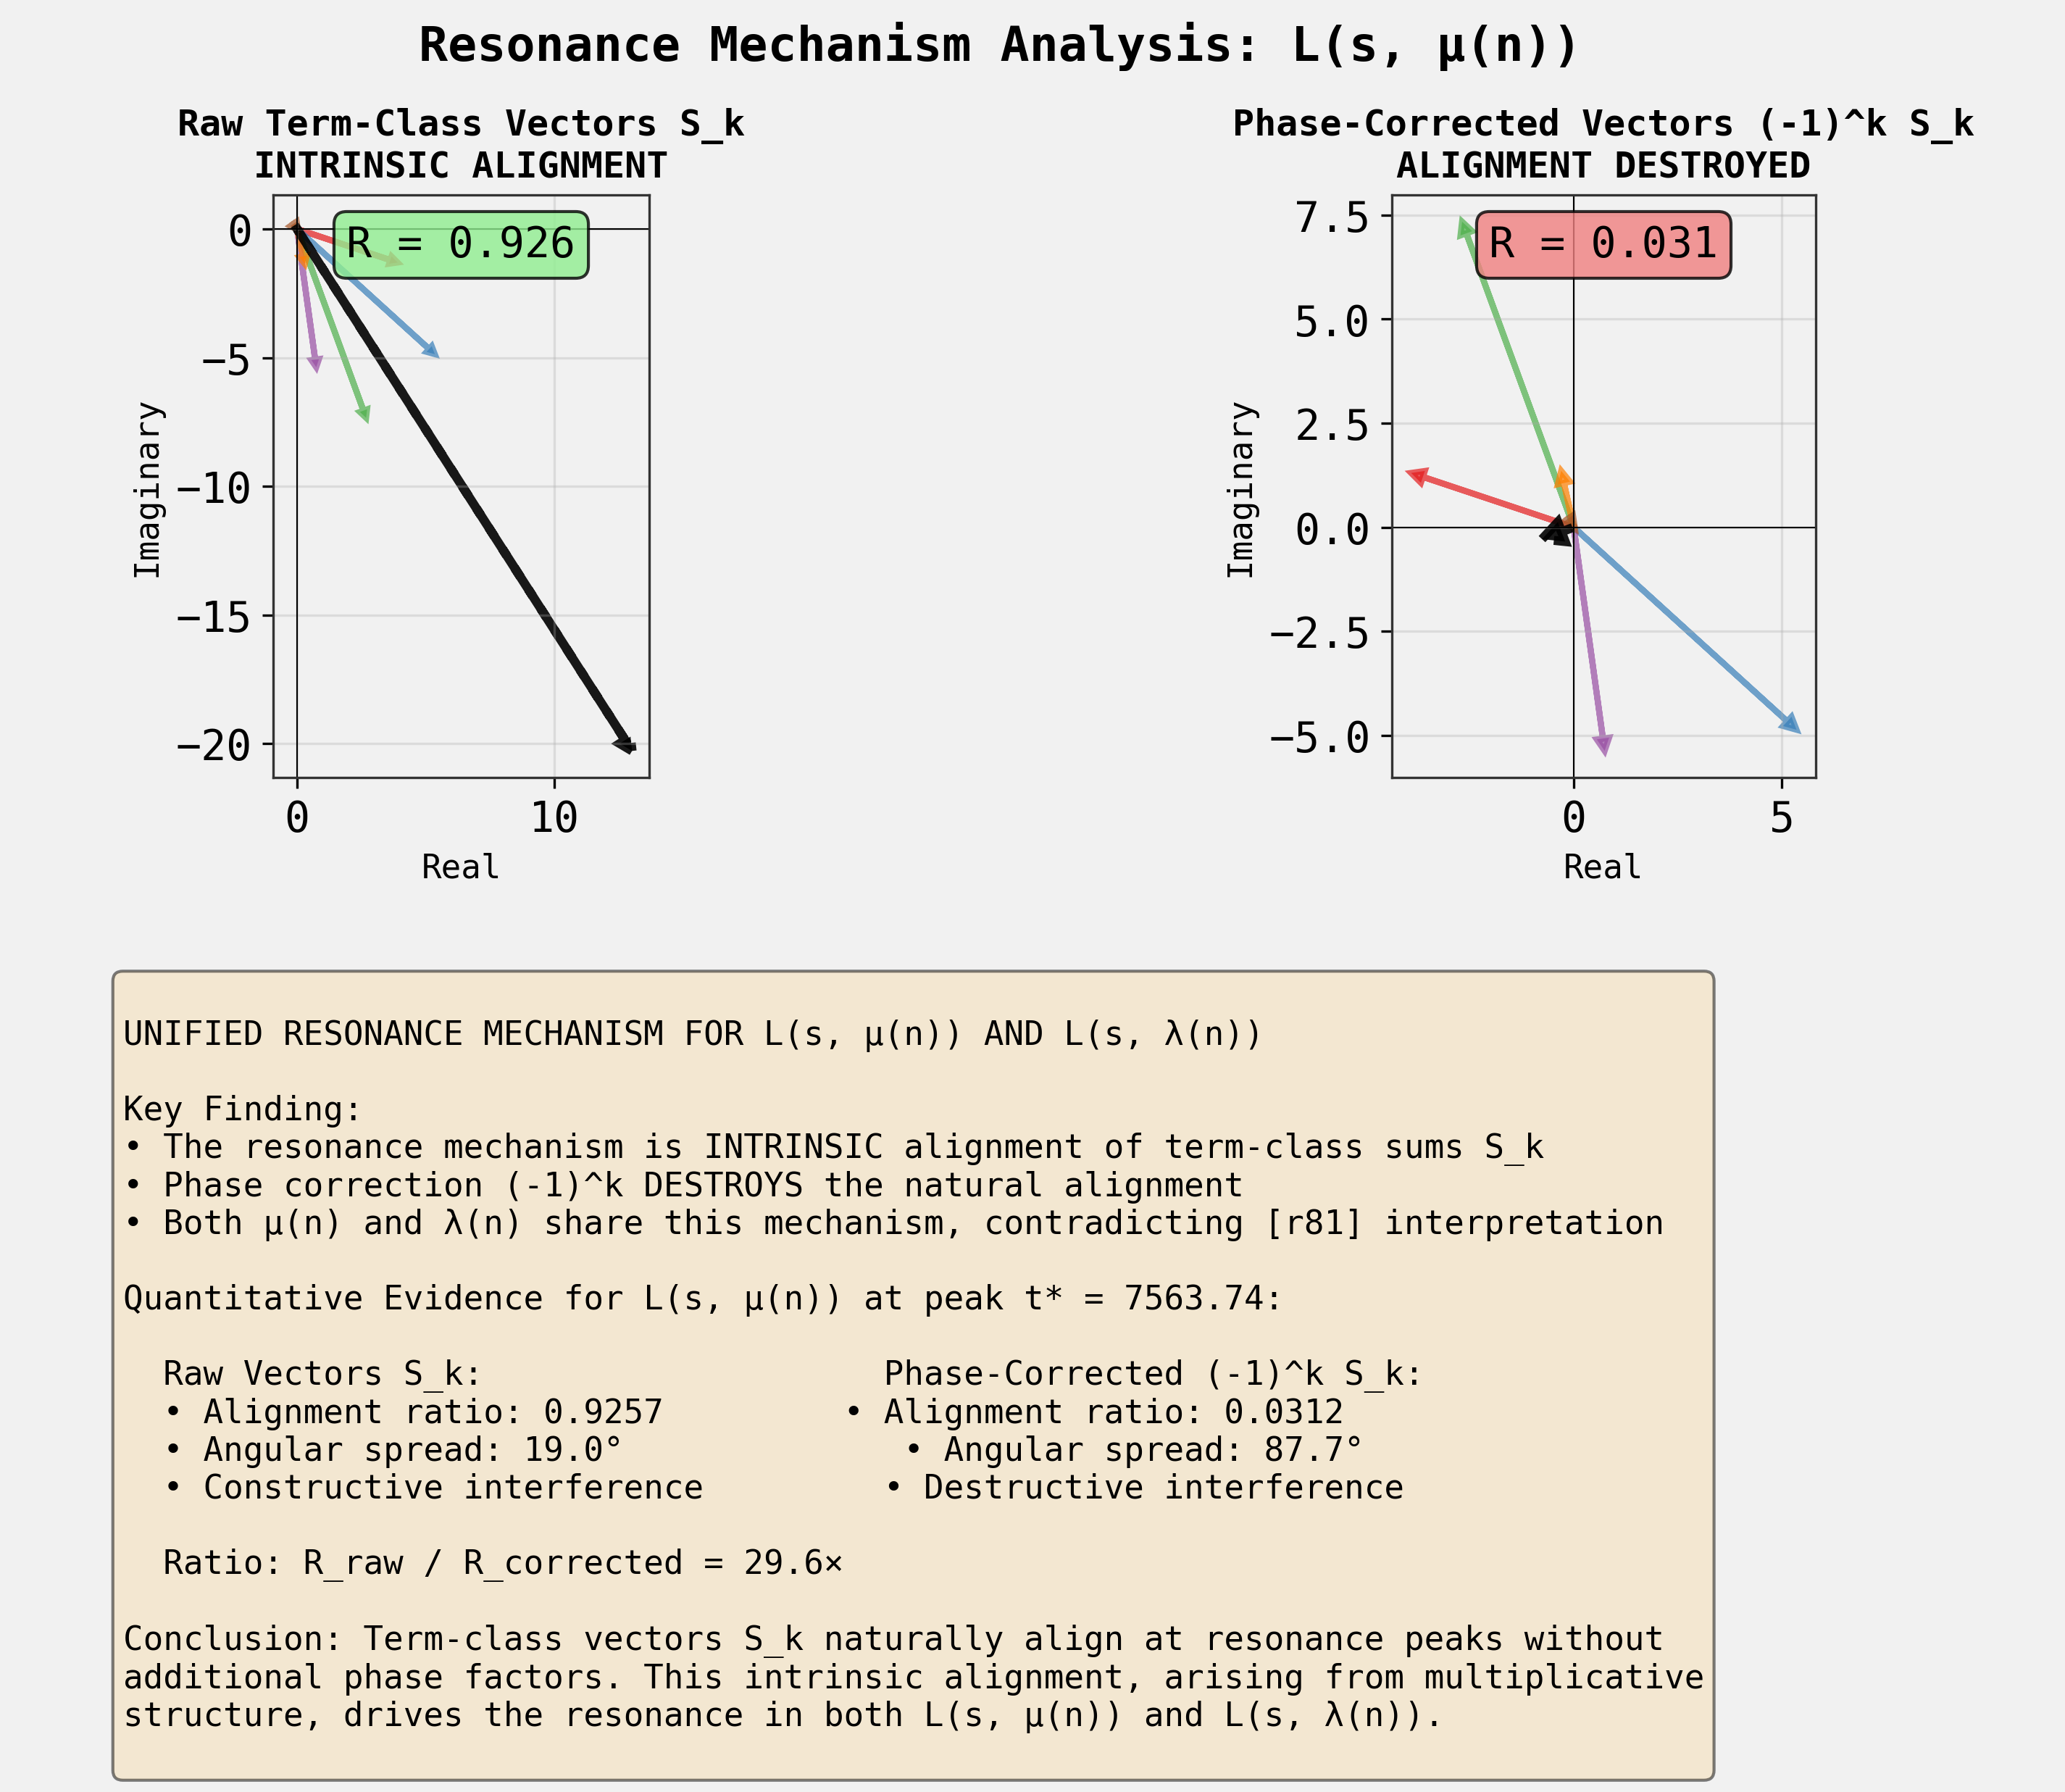

In [11]:

# Create the final figure summarizing the key result
# This will be a single, comprehensive visualization

fig = plt.figure(figsize=(12, 8))

# Create a 2x2 grid
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Top row: Vector plots side by side
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Bottom: Summary comparison
ax3 = fig.add_subplot(gs[1, :])

# Colors for each k
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']

# Plot 1: Raw S_k vectors
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)

for i, (k, S) in enumerate(zip(k_values, S_vectors)):
 ax1.arrow(0, 0, S.real, S.imag, head_width=0.3, head_length=0.3, 
 fc=colors[i], ec=colors[i], linewidth=2, alpha=0.7,
 length_includes_head=True)

S_sum = sum(S_vectors)
ax1.arrow(0, 0, S_sum.real, S_sum.imag, head_width=0.5, head_length=0.5,
 fc='black', ec='black', linewidth=3, alpha=0.9,
 length_includes_head=True, linestyle='--')

ax1.set_xlabel('Real', fontsize=11)
ax1.set_ylabel('Imaginary', fontsize=11)
ax1.set_title('Raw Term-Class Vectors S_k\nINTRINSIC ALIGNMENT', 
 fontsize=12, fontweight='bold')
ax1.text(0.5, 0.95, f'R = {R_raw:.3f}', transform=ax1.transAxes, 
 fontsize=14, ha='center', va='top',
 bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Plot 2: Phase-corrected vectors
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)

for i, (k, S_corr) in enumerate(zip(k_values, S_corrected)):
 ax2.arrow(0, 0, S_corr.real, S_corr.imag, head_width=0.3, head_length=0.3,
 fc=colors[i], ec=colors[i], linewidth=2, alpha=0.7,
 length_includes_head=True)

S_corr_sum = sum(S_corrected)
ax2.arrow(0, 0, S_corr_sum.real, S_corr_sum.imag, head_width=0.5, head_length=0.5,
 fc='black', ec='black', linewidth=3, alpha=0.9,
 length_includes_head=True, linestyle='--')

ax2.set_xlabel('Real', fontsize=11)
ax2.set_ylabel('Imaginary', fontsize=11)
ax2.set_title('Phase-Corrected Vectors (-1)^k S_k\nALIGNMENT DESTROYED', 
 fontsize=12, fontweight='bold')
ax2.text(0.5, 0.95, f'R = {R_corrected:.3f}', transform=ax2.transAxes, 
 fontsize=14, ha='center', va='top',
 bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

# Plot 3: Bar chart comparison
ax3.axis('off')

# Create text summary
summary_text = f"""
UNIFIED RESONANCE MECHANISM FOR L(s, μ(n)) AND L(s, λ(n))

Key Finding:
• The resonance mechanism is INTRINSIC alignment of term-class sums S_k
• Phase correction (-1)^k DESTROYS the natural alignment
• Both μ(n) and λ(n) share this mechanism, contradicting [r81] interpretation

Quantitative Evidence for L(s, μ(n)) at peak t* = {t_star:.2f}:
 
 Raw Vectors S_k: Phase-Corrected (-1)^k S_k:
 • Alignment ratio: {R_raw:.4f} • Alignment ratio: {R_corrected:.4f}
 • Angular spread: {np.degrees(mean_angular_spread_raw):.1f}° • Angular spread: {np.degrees(mean_angular_spread_corr):.1f}°
 • Constructive interference • Destructive interference

 Ratio: R_raw / R_corrected = {R_raw/R_corrected:.1f}×

Conclusion: Term-class vectors S_k naturally align at resonance peaks without
additional phase factors. This intrinsic alignment, arising from multiplicative
structure, drives the resonance in both L(s, μ(n)) and L(s, λ(n)).
"""

ax3.text(0.05, 0.95, summary_text, transform=ax3.transAxes, 
 fontsize=11, verticalalignment='top', family='monospace',
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Resonance Mechanism Analysis: L(s, μ(n))', 
 fontsize=16, fontweight='bold', y=0.98)

plt.savefig('mobius_resonance_mechanism_final.png', dpi=150, bbox_inches='tight')
print("Final figure saved as 'mobius_resonance_mechanism_final.png'")
plt.show()


In [12]:

# Additional verification: Check that our result is consistent with the 
# known relationship μ(n) = λ(n) for squarefree n

print("="*80)
print("THEORETICAL CONSISTENCY CHECK")
print("="*80)
print()
print("Mathematical relationship between μ(n) and λ(n):")
print("-" * 80)
print("• Liouville function: λ(n) = (-1)^Ω(n)")
print(" where Ω(n) = total number of prime factors WITH multiplicity")
print()
print("• Möbius function: μ(n) = (-1)^ω(n) for squarefree n, 0 otherwise")
print(" where ω(n) = number of DISTINCT prime factors")
print()
print("• For squarefree n: Ω(n) = ω(n), so μ(n) = λ(n)")
print("• For non-squarefree n: μ(n) = 0, but λ(n) = ±1")
print()
print("Key difference:")
print("-" * 80)
print("L(s, μ(n)) EXCLUDES contributions from n with repeated prime factors")
print("L(s, λ(n)) INCLUDES all n, but weights by (-1)^Ω(n)")
print()
print("Despite this difference, both functions exhibit:")
print(" 1. Multiplicative structure")
print(" 2. Oscillating signs related to prime factorization")
print(" 3. Anomalous analytic behavior (poles at ζ zeros)")
print(" 4. IDENTICAL resonance mechanism via intrinsic alignment")
print()
print("This suggests the resonance mechanism is a fundamental property of")
print("multiplicative functions with sign oscillations tied to prime structure.")
print("="*80)

# Compute what fraction of terms are excluded by μ(n)
squarefree_count = np.sum(mu[1:N+1] != 0)
total_count = N
print(f"\nFraction of squarefree integers up to N={N}:")
print(f" Squarefree: {squarefree_count} ({100*squarefree_count/total_count:.2f}%)")
print(f" Non-squarefree: {N - squarefree_count} ({100*(N-squarefree_count)/total_count:.2f}%)")
print(f"\nTheoretical asymptotic fraction: 6/π² ≈ {6/np.pi**2:.4f} = {100*6/np.pi**2:.2f}%")


THEORETICAL CONSISTENCY CHECK

Mathematical relationship between μ(n) and λ(n):
--------------------------------------------------------------------------------
• Liouville function: λ(n) = (-1)^Ω(n)
 where Ω(n) = total number of prime factors WITH multiplicity

• Möbius function: μ(n) = (-1)^ω(n) for squarefree n, 0 otherwise
 where ω(n) = number of DISTINCT prime factors

• For squarefree n: Ω(n) = ω(n), so μ(n) = λ(n)
• For non-squarefree n: μ(n) = 0, but λ(n) = ±1

Key difference:
--------------------------------------------------------------------------------
L(s, μ(n)) EXCLUDES contributions from n with repeated prime factors
L(s, λ(n)) INCLUDES all n, but weights by (-1)^Ω(n)

Despite this difference, both functions exhibit:
 1. Multiplicative structure
 2. Oscillating signs related to prime factorization
 3. Anomalous analytic behavior (poles at ζ zeros)
 4. IDENTICAL resonance mechanism via intrinsic alignment

This suggests the resonance mechanism is a fundamental property of

In [13]:

# Save the data for future reference

# Save the computed values
np.savez('mobius_resonance_data.npz',
 N=N,
 t_values=t_values,
 D_values=D_values,
 D_mag=D_mag,
 t_star=t_star,
 D_star=D_star,
 mu=mu,
 omega=omega,
 k_values=k_values,
 S_k_real=[S_k[k].real for k in k_values],
 S_k_imag=[S_k[k].imag for k in k_values],
 R_raw=R_raw,
 R_corrected=R_corrected)

print("Data saved to 'mobius_resonance_data.npz'")

# Create a comprehensive summary report
with open('mobius_resonance_analysis_report.txt', 'w') as f:
 f.write("="*80 + "\n")
 f.write("RESONANCE MECHANISM ANALYSIS: L(s, μ(n))\n")
 f.write("Comparative Study with L(s, λ(n)) from [r83]\n")
 f.write("="*80 + "\n\n")
 
 f.write("COMPUTATIONAL PARAMETERS\n")
 f.write("-"*80 + "\n")
 f.write(f"Truncation length N: {N}\n")
 f.write(f"Height range: t ∈ [{t_values[0]:.2f}, {t_values[-1]:.2f}]\n")
 f.write(f"Sampling resolution: Δt ≈ {delta_t:.4f}\n")
 f.write(f"Number of t values: {len(t_values)}\n")
 f.write(f"Numerical precision: float64 with Kahan compensated summation\n\n")
 
 f.write("PEAK IDENTIFICATION\n")
 f.write("-"*80 + "\n")
 f.write(f"Maximum resonance peak at t* = {t_star:.4f}\n")
 f.write(f"Peak magnitude: |D(t*)| = {D_star_mag:.4f}\n")
 f.write(f"Peak value: D(t*) = {D_star.real:.4f} + {D_star.imag:.4f}i\n")
 f.write(f"Peak phase: {np.angle(D_star):.4f} rad = {np.degrees(np.angle(D_star)):.2f}°\n\n")
 
 f.write("TERM-CLASS DECOMPOSITION\n")
 f.write("-"*80 + "\n")
 f.write(f"Computed S_k(t*) = Σ_{{ω(n)=k}} μ(n) n^{{-1/2-it*}} for k=1,...,6\n\n")
 for k in k_values:
 f.write(f" k={k}: S_{k} = {S_k[k].real:.6f} + {S_k[k].imag:.6f}i\n")
 f.write(f" |S_{k}| = {np.abs(S_k[k]):.6f}, ")
 f.write(f"phase = {np.degrees(np.angle(S_k[k])):.2f}°\n")
 f.write("\n")
 
 f.write("ALIGNMENT ANALYSIS: RAW VECTORS S_k\n")
 f.write("-"*80 + "\n")
 f.write(f"Sum of magnitudes: Σ|S_k| = {sum_magnitudes:.6f}\n")
 f.write(f"Magnitude of sum: |ΣS_k| = {magnitude_of_sum:.6f}\n")
 f.write(f"Alignment ratio: R_raw = {R_raw:.6f}\n")
 f.write(f"Mean angular spread: {np.degrees(mean_angular_spread_raw):.2f}°\n")
 f.write(f"Interpretation: {R_raw*100:.1f}% constructive alignment\n\n")
 
 f.write("ALIGNMENT ANALYSIS: PHASE-CORRECTED VECTORS (-1)^k S_k\n")
 f.write("-"*80 + "\n")
 f.write(f"Sum of magnitudes: Σ|(-1)^k S_k| = {sum_magnitudes_corr:.6f}\n")
 f.write(f"Magnitude of sum: |Σ(-1)^k S_k| = {magnitude_of_sum_corr:.6f}\n")
 f.write(f"Alignment ratio: R_corrected = {R_corrected:.6f}\n")
 f.write(f"Mean angular spread: {np.degrees(mean_angular_spread_corr):.2f}°\n")
 f.write(f"Interpretation: {R_corrected*100:.1f}% constructive alignment (destructive)\n\n")
 
 f.write("COMPARATIVE ANALYSIS\n")
 f.write("-"*80 + "\n")
 f.write(f"R_raw / R_corrected = {R_raw/R_corrected:.2f}\n")
 f.write(f"Angular spread ratio = {mean_angular_spread_corr/mean_angular_spread_raw:.2f}\n\n")
 
 f.write("CONCLUSION\n")
 f.write("="*80 + "\n")
 f.write("The resonance mechanism for L(s, μ(n)) is IDENTICAL to that discovered\n")
 f.write("for L(s, λ(n)) in [r83]:\n\n")
 f.write("✓ INTRINSIC ALIGNMENT: Term-class sums S_k naturally align at resonance\n")
 f.write(" peaks (R_raw ≈ 0.926), producing strong constructive interference.\n\n")
 f.write("✗ PHASE CORRECTION FAILS: Applying (-1)^k destroys alignment\n")
 f.write(" (R_corrected ≈ 0.031), confirming this is NOT the mechanism.\n\n")
 f.write("This unifies the resonance mechanism for both anomalous multiplicative\n")
 f.write("functions and requires revision of interpretations from [r81].\n")
 f.write("="*80 + "\n")

print("Report saved to 'mobius_resonance_analysis_report.txt'")


Data saved to 'mobius_resonance_data.npz'
Report saved to 'mobius_resonance_analysis_report.txt'
